# **News Category Classification with RNN**

# Text Preprocessing, Tokenization, and Sequence Padding

# Load Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# load csv file
df = pd.read_csv("/content/drive/MyDrive/AI-Sem6/Assessment/language_task/news_category.csv")


In [3]:
# strip extra spaces from column names
df.columns = df.columns.str.strip()

#column names
text_col = "headline" # column with the text
label_col = "category" # column with the class label

In [4]:
# Keep only the two columns needed
df_text = df[[text_col, label_col]].copy()

In [5]:
print(" Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())


 Dataset Shape: (11025, 2)
Columns: ['headline', 'category']


In [6]:
# examples in each category
print("\nClass distribution:")
print(df_text[label_col].value_counts())


Class distribution:
category
SPORTS            5077
TECH              2104
MONEY             1756
CULTURE & ARTS    1074
EDUCATION         1014
Name: count, dtype: int64


In [7]:
print("\nMissing values:")
print(df_text.isnull().sum())


Missing values:
headline    0
category    0
dtype: int64


In [8]:
df.head()

,headline,category
0,How A New Documentary Captures The Complexity ...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",SPORTS


# Clean the text



In [9]:
# Required imports
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

True

In [10]:
# Stopwords and lemmatizer
Stop_words = set(stopwords.words("english"))
Lemmatizer = WordNetLemmatizer()

In [11]:
# Contractions dictionary
contractions = {
    "don't": "do not",   "doesn't": "does not",  "didn't": "did not",
    "can't": "cannot",   "couldn't": "could not", "won't": "will not",
    "wouldn't": "would not", "shouldn't": "should not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not",     "weren't": "were not",
    "it's": "it is",     "that's": "that is",     "what's": "what is",
    "i'm": "i am",       "i've": "i have",        "i'll": "i will",
    "i'd": "i would",    "you're": "you are",     "you've": "you have",
    "they're": "they are", "we're": "we are",     "he's": "he is",
    "she's": "she is",
}

**Lowercase all text to ensure uniformity.**

In [12]:
def lower_order(text: str) -> str:
    # Convert text to lowercase
    return text.lower()

**Handle contractions (e.g., "don’t" → "do not").**

In [13]:
def handle_contractions(text: str) -> str:
    text = text.replace("’", "'").replace("‘", "'")

    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)

    return text

**Remove URLs, mentions (@user), hashtags (#), numbers, and special characters.**

In [14]:
def remove_urls(text: str) -> str:
    # Remove URLs from text
    return re.sub(r"https?://\S+|www\.\S+", " ", text)

In [15]:
def remove_emoji(text: str) -> str:
    # Remove emojis from text
    emoji_pattern = re.compile(
        "[" + u"\U0001F600-\U0001F64F" + u"\U0001F300-\U0001F5FF"
            + u"\U0001F680-\U0001F6FF" + u"\U0001F1E0-\U0001F1FF"
            + u"\U00002702-\U000027B0" + u"\U000024C2-\U0001F251" + "]+",
        flags=re.UNICODE
    )

    return emoji_pattern.sub(" ", text)

In [16]:
def remove_unwanted_characters(text: str) -> str:
    text = re.sub(r"@\w+", " ", text)      # remove full mentions
    text = re.sub(r"#\w+", " ", text)      # remove full hashtags
    text = re.sub(r"\d+", " ", text)       # remove numbers
    text = re.sub(r"[^A-Za-z ]", " ", text)
    return text

In [17]:
def remove_extra_spaces(text: str) -> str:
    # Remove extra spaces
    return re.sub(r" +", " ", text).strip()

In [18]:
def tokenization(text: str) -> list:
    # Split sentence into words
    return text.split()

**Remove stopwords and lemmatize words to reduce words to their base form.**

In [19]:
def remove_stopwords(text_tokens: list) -> list:
    filtered_tokens = []

    for token in text_tokens:
        if token not in Stop_words:
            filtered_tokens.append(token)

    return filtered_tokens

In [20]:
def lemmatization(token_text: list) -> list:
    lemmatized_tokens = []

    for token in token_text:
        lemmatized_tokens.append(Lemmatizer.lemmatize(token, pos="v"))

    return lemmatized_tokens

**Text Cleaning Pipeline**

In [21]:
def clean_text(text: str) -> str:
    # lowercase
    text = lower_order(text)

    # expand contractions
    text = handle_contractions(text)

    # remove URLs
    text = remove_urls(text)

    # remove emojis
    text = remove_emoji(text)

    # remove unwanted characters
    text = remove_unwanted_characters(text)

    # remove extra spaces
    text = remove_extra_spaces(text)

    # tokenize text into words
    tokens = tokenization(text)

    # remove stopwords
    tokens = remove_stopwords(tokens)

    # lemmatize words
    tokens = lemmatization(tokens)

    # join words back into sentence
    text = " ".join(tokens)

    return text

**Sample text sentence from dataset**

In [22]:
# Test on one sample headline
sample = df_text[text_col].iloc[0]

print("Original :", sample)
print("Cleaned  :", clean_text(sample))

Original : How A New Documentary Captures The Complexity Of Being A Child Of Immigrants
Cleaned  : new documentary capture complexity child immigrants


**Apply to entire dataset**

In [23]:
# Apply cleaning to the full dataset
df_text["cleaned_headline"] = df_text[text_col].apply(clean_text)

**Check for empty headline**

In [24]:
empty_count = (df_text["cleaned_headline"] == "").sum()
print(f"Empty headlines removed: {empty_count}")

Empty headlines removed: 0


**Display shape of dataset after cleaning**

In [25]:
df_text = df_text[df_text["cleaned_headline"] != ""].reset_index(drop=True)

print("Dataset shape after cleaning:", df_text.shape)

df_text[[text_col, "cleaned_headline", label_col]].head()

Dataset shape after cleaning: (11025, 3)


,headline,cleaned_headline,category
0,How A New Documentary Captures The Complexity ...,new documentary capture complexity child immig...,CULTURE & ARTS
1,Twitch Bans Gambling Sites After Streamer Scam...,twitch ban gamble sit streamer scam folks,TECH
2,'Reboot' Is A Clever And Not Too Navel-Gazey L...,reboot clever navel gazey look inside tv reboot,CULTURE & ARTS
3,"Maury Wills, Base-Stealing Shortstop For Dodge...",maury will base steal shortstop dodgers die,SPORTS
4,"Las Vegas Aces Win First WNBA Title, Chelsea G...",las vegas ace win first wnba title chelsea gra...,SPORTS


# Visualize the cleaned data:

**Bar chart of 20 most frequent words**

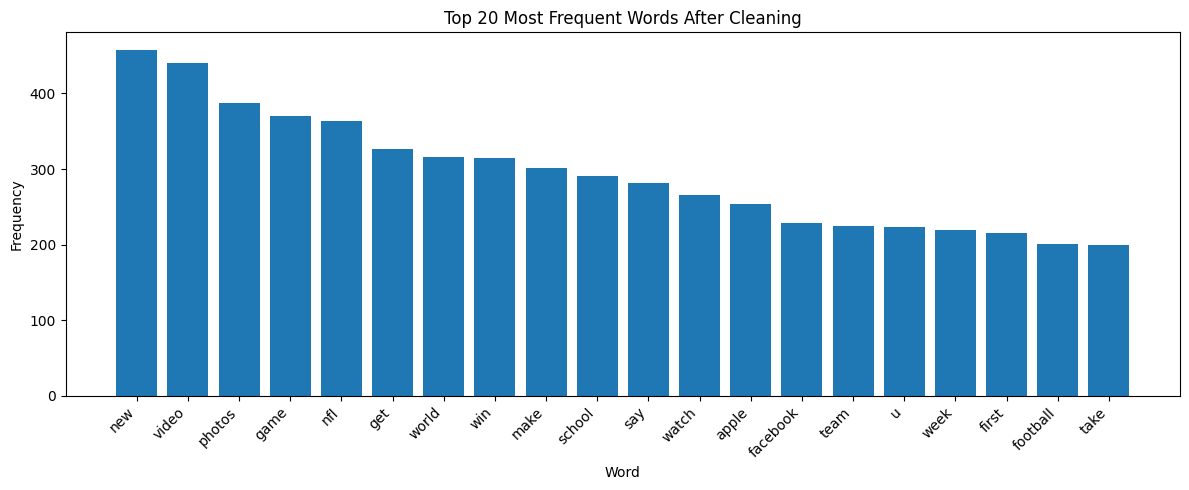

In [26]:
from collections import Counter
import matplotlib.pyplot as plt

# Split all cleaned headlines into individual words and count them
all_words = " ".join(df_text["cleaned_headline"]).split()

word_freq = Counter(all_words)          # Count how many times each word appears
top20 = word_freq.most_common(20)       # Get the 20 most common words

word_df = pd.DataFrame(top20, columns=["word", "frequency"])

plt.figure(figsize=(12, 5))
plt.bar(word_df["word"], word_df["frequency"])
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Most frequent words as large text and rare words as small text**

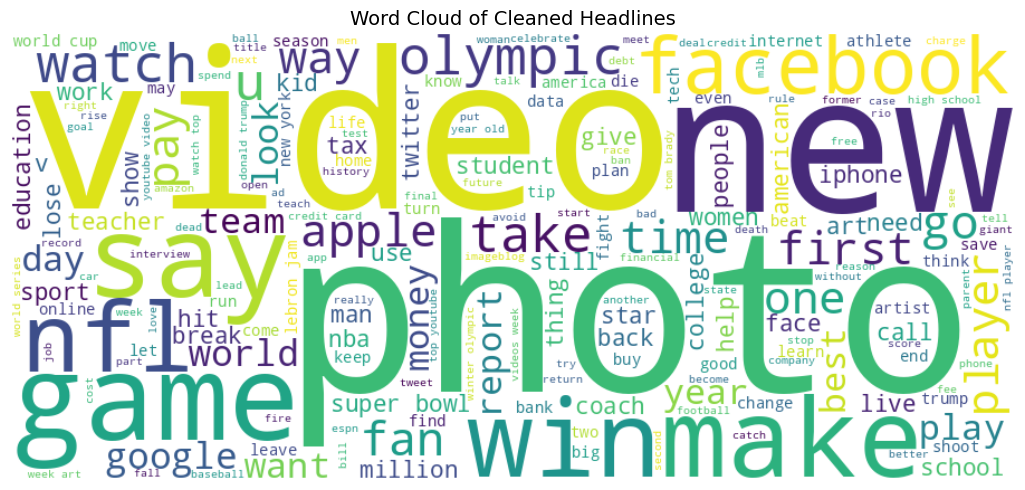

In [27]:
from wordcloud import WordCloud

# Word cloud shows the most frequent words as large text and rare words as small text

wordcloud = WordCloud(
    width=900,
    height=400,
    background_color="white",
    max_words=200,      # show up to 200 words
    colormap="viridis"  # colour scheme
).generate(" ".join(df_text["cleaned_headline"]))

plt.figure(figsize=(12, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # hide x and y axes
plt.title("Word Cloud of Cleaned Headlines", fontsize=14)
plt.tight_layout()
plt.show()

**Encode category labels**

In [28]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Convert category labels into numeric values
df_text["encoded_category"] = label_encoder.fit_transform(df_text[label_col])

# Show category to integer mapping
print("Category → Integer mapping:")

for idx, cat in enumerate(label_encoder.classes_):
    print(f"  {cat:30s} → {idx}")

Category → Integer mapping:
  CULTURE & ARTS                 → 0
  EDUCATION                      → 1
  MONEY                          → 2
  SPORTS                         → 3
  TECH                           → 4


**Split the dataset into 80% training and 20% testing using train test split.**

In [29]:
from sklearn.model_selection import train_test_split

# Input text and target labels
X = df_text["cleaned_headline"]      # input text
y = df_text["encoded_category"]      # target labels as integers

# Split dataset into training and testing sets
# 80% training data, 20% testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42, #same split every time we run the code
    stratify=y #keeps the same category balance in train and test sets
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Training samples : 8820
Testing samples  : 2205


# Tokenization and Padding:



**Use Keras Tokenizer to convert the text into sequences of integers.**

In [30]:
from tensorflow.keras.preprocessing.text import Tokenizer

vocab_size = 10000      # only keep the 10,000 most common words
oov_token = "<OOV>"     # words not seen during training get this special token

# Tokenizer learns the vocabulary from training data only
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)

# Learn word → integer mapping from the training set
tokenizer.fit_on_texts(X_train)

# Convert each headline from words into a list of integers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Full word → integer dictionary
word_index = tokenizer.word_index

print(f"Unique tokens in training set: {len(word_index)}")
print("Sample sequence:", X_train_seq[0])

Unique tokens in training set: 10693
Sample sequence: [62, 60, 14, 412, 2113, 431]


**Percentile-based padding**

95th-percentile sequence length → max_length = 11


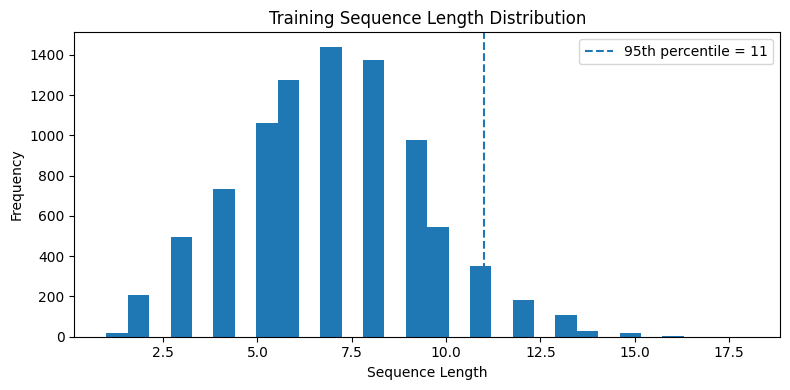

In [31]:
import numpy as np

seq_lengths = [len(s) for s in X_train_seq]

max_length = int(np.percentile(seq_lengths, 95))

print(f"95th-percentile sequence length → max_length = {max_length}")

# Histogram shows how lengths are distributed and where our cut-off falls
plt.figure(figsize=(8, 4))
plt.hist(seq_lengths, bins=30)
plt.axvline(max_length, linestyle="--", label=f"95th percentile = {max_length}")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.title("Training Sequence Length Distribution")
plt.legend()
plt.tight_layout()
plt.show()



In [32]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

x_train_padded = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

x_test_padded = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

# Convert labels to numpy arrays because Keras works better with numpy arrays
y_train = np.array(y_train)
y_test = np.array(y_test)

# Actual vocabulary size used in the embedding layer
total_words = min(vocab_size, len(word_index) + 1)

# Number of output categories
num_classes = len(label_encoder.classes_)

print(f"x_train_padded shape : {x_train_padded.shape}")
print(f"x_test_padded shape  : {x_test_padded.shape}")
print(f"Effective vocabulary : {total_words}")
print(f"Number of classes    : {num_classes}")
print(f"Max sequence length  : {max_length}")

x_train_padded shape : (8820, 11)
x_test_padded shape  : (2205, 11)
Effective vocabulary : 10000
Number of classes    : 5
Max sequence length  : 11


# **Model Building and Training:**


In [33]:
from tensorflow.keras.callbacks import EarlyStopping

embedding_dim = 100   # size of the word vector for models 1 and 2
rnn_units = 64        # number of memory units in the RNN/LSTM layer
epochs = 15           # maximum number of training rounds
batch_size = 32       # number of samples processed before weights are updated
val_split = 0.2       # 20% of training data used for validation

# EarlyStopping stops training if validation loss does not improve for 3 epochs
# restore_best_weights=True brings back the best model weights
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)


# 1. Simple RNN with a trainable Embedding layer.

In [34]:
# Required imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dropout, Dense

In [35]:
rnn_model = Sequential([
    # This layer learns word vectors during training
    Embedding(
        input_dim=total_words,
        output_dim=embedding_dim,
        input_length=max_length
    ),
    SimpleRNN(rnn_units),

    # Randomly switches off 30% of neurons during training
    Dropout(0.3),

    Dense(num_classes, activation="softmax"),
], name="simple_rnn_model")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [36]:
rnn_model.summary()

Model: "simple_rnn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 2. LSTM with a trainable Embedding layer.

In [37]:
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense

lstm_model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=embedding_dim,
        input_length=max_length
    ),
    # Uses gates to decide what to remember and what to forget
    LSTM(rnn_units),

    # Dropout helps reduce overfitting
    Dropout(0.3),

    Dense(num_classes, activation="softmax"),
], name="lstm_trainable_embedding")

In [38]:
lstm_model.summary()

Model: "lstm_trainable_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 3. LSTM with pretrained Word2Vec embeddings.

In [39]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 41.5 MB/s eta 0:00:00


In [40]:
import gensim.downloader as api

print("Downloading pretrained Word2Vec embeddings.")

word2vec_model = api.load("word2vec-google-news-300")

word2vec_dim = 300  # match the pretrained Word2Vec model

embedding_matrix = np.zeros((total_words, word2vec_dim))

missing = 0

for word, idx in word_index.items():
    if idx < total_words:
        if word in word2vec_model:
            embedding_matrix[idx] = word2vec_model[word]
        else:
            missing += 1

coverage = (1 - missing / total_words) * 100

print(f"Word2Vec vocabulary coverage: {coverage:.1f}% ({missing} words not in Word2Vec)")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec vocabulary coverage: 84.5% (1545 words not in Word2Vec)


In [41]:
word2vec_lstm_model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=word2vec_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False
    ),

    # LSTM layer
    LSTM(rnn_units),

    # Dropout helps reduce overfitting
    Dropout(0.3),

    # Output layer
    Dense(num_classes, activation="softmax"),
], name="lstm_pretrained_word2vec")

word2vec_lstm_model.summary()

Model: "lstm_pretrained_word2vec"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,000,000 (11.44 MB)

# **Model Training and Evaluation**

**Compile the models**

In [42]:
rnn_model.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [43]:
lstm_model.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

In [44]:
word2vec_lstm_model.compile(
    loss = "sparse_categorical_crossentropy",
    optimizer = "adam",
    metrics = ["accuracy"]
)

**Train the models using callbacks and early stopping**

In [45]:
print("Training Model 1: Simple RNN")
rnn_history = rnn_model.fit(
    x_train_padded,
    y_train,
    epochs = epochs,
    batch_size = batch_size,
    validation_split = val_split,
    callbacks = [early_stop],
    verbose = 1
)

Training Model 1: Simple RNN
Epoch 1/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.6379 - loss: 0.9627 - val_accuracy: 0.7755 - val_loss: 0.6561
Epoch 2/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9052 - loss: 0.2953 - val_accuracy: 0.8084 - val_loss: 0.5748
Epoch 3/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9762 - loss: 0.0874 - val_accuracy: 0.8005 - val_loss: 0.6954
Epoch 4/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9875 - loss: 0.0463 - val_accuracy: 0.7829 - val_loss: 0.8521
Epoch 5/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9942 - loss: 0.0221 - val_accuracy: 0.7880 - val_loss: 0.9081
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [46]:
print("Training Model 2: LSTM with trainable embedding")
lstm_history = lstm_model.fit(
    x_train_padded,
    y_train,
    epochs = epochs,
    batch_size = batch_size,
    validation_split = val_split,
    callbacks = [early_stop],
    verbose = 1
)

Training Model 2: LSTM with trainable embedding
Epoch 1/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.5853 - loss: 1.0515 - val_accuracy: 0.7404 - val_loss: 0.6598
Epoch 2/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8615 - loss: 0.4119 - val_accuracy: 0.8367 - val_loss: 0.5019
Epoch 3/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9517 - loss: 0.1639 - val_accuracy: 0.8328 - val_loss: 0.5210
Epoch 4/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9795 - loss: 0.0802 - val_accuracy: 0.8141 - val_loss: 0.6496
Epoch 5/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9872 - loss: 0.0473 - val_accuracy: 0.8214 - val_loss: 0.7283
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [47]:
print("Training Model 3: LSTM with word2vec embedding")
word2vec_lstm_history = word2vec_lstm_model.fit(
    x_train_padded,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=val_split,
    callbacks=[early_stop],
    verbose=1
)

Training Model 3: LSTM with word2vec embedding
Epoch 1/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7348 - loss: 0.7504 - val_accuracy: 0.8231 - val_loss: 0.5106
Epoch 2/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8608 - loss: 0.4242 - val_accuracy: 0.8413 - val_loss: 0.4580
Epoch 3/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - accuracy: 0.8788 - loss: 0.3710 - val_accuracy: 0.8464 - val_loss: 0.4441
Epoch 4/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8943 - loss: 0.3320 - val_accuracy: 0.8532 - val_loss: 0.4577
Epoch 5/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.8982 - loss: 0.3052 - val_accuracy: 0.8452 - val_loss: 0.4653
Epoch 6/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9106 - loss: 0.2803 - val_accuracy: 0.8475 - val_loss: 0.4682
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.


# Visualization

**Plot the Training vs. Validation loss and accuracy over epochs.**

In [ ]:
def plot_history(history, model_name: str):
    """
    Plots two graphs side by side for a trained model:
    Left:  Training accuracy vs validation accuracy per epoch
    Right: Training loss vs validation loss per epoch

    If training accuracy is much higher than validation accuracy → overfitting
    If both are low → underfitting
    """

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy plot
    axes[0].plot(history.history["accuracy"], label="Train")
    axes[0].plot(history.history["val_accuracy"], label="Validation", linestyle="--")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"{model_name} — Accuracy")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss plot
    axes[1].plot(history.history["loss"], label="Train")
    axes[1].plot(history.history["val_loss"], label="Validation", linestyle="--")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].set_title(f"{model_name} — Loss")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(model_name, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

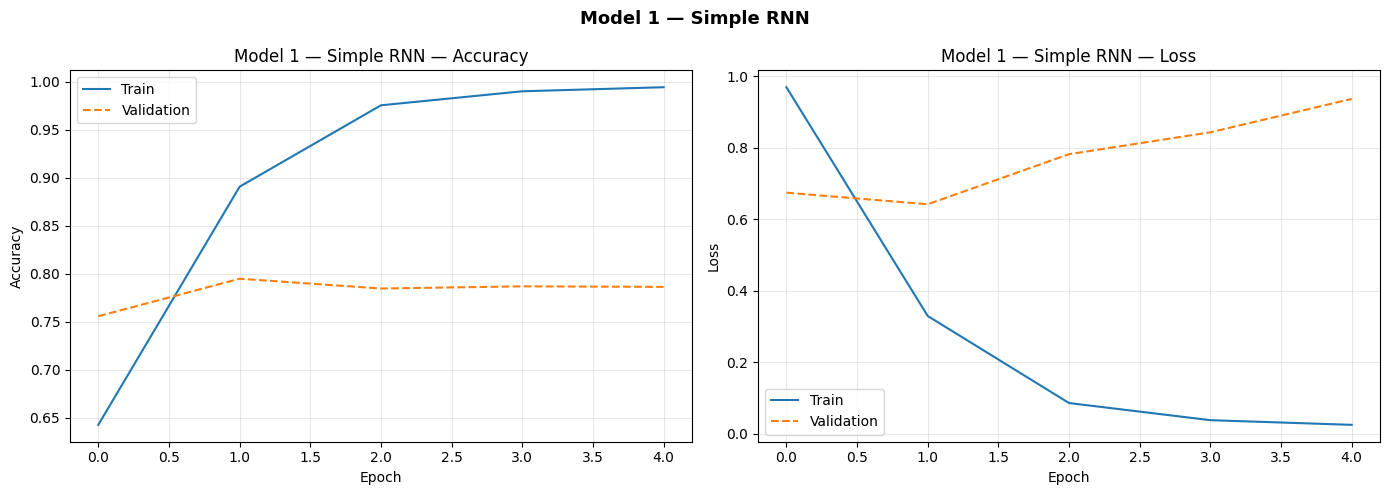

In [ ]:
plot_history(rnn_history, "Model 1 — Simple RNN")

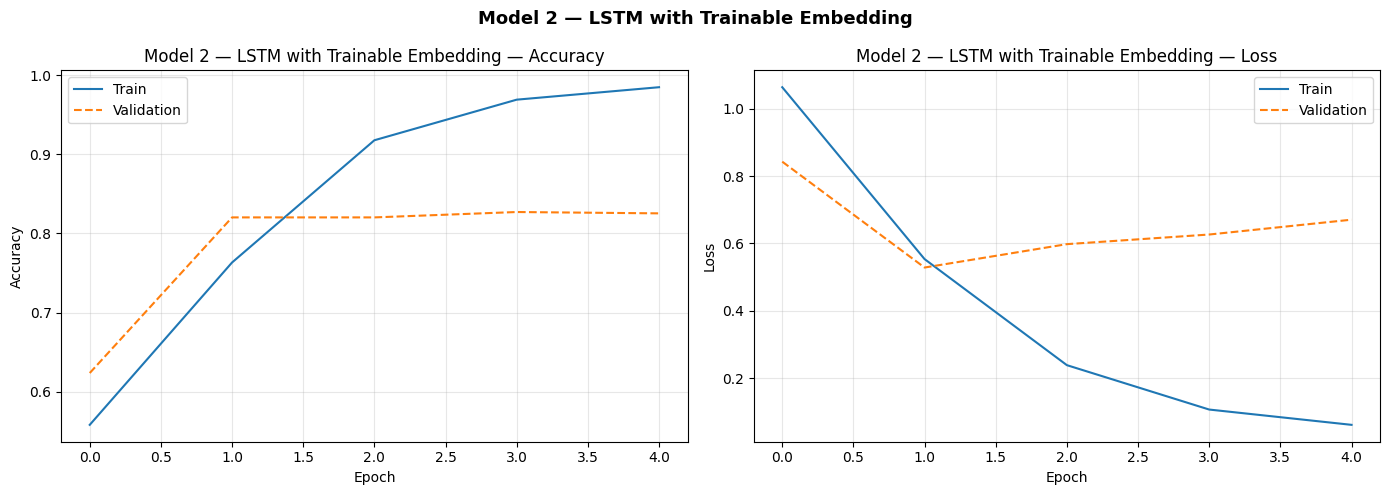

In [ ]:
plot_history(lstm_history, "Model 2 — LSTM with Trainable Embedding")

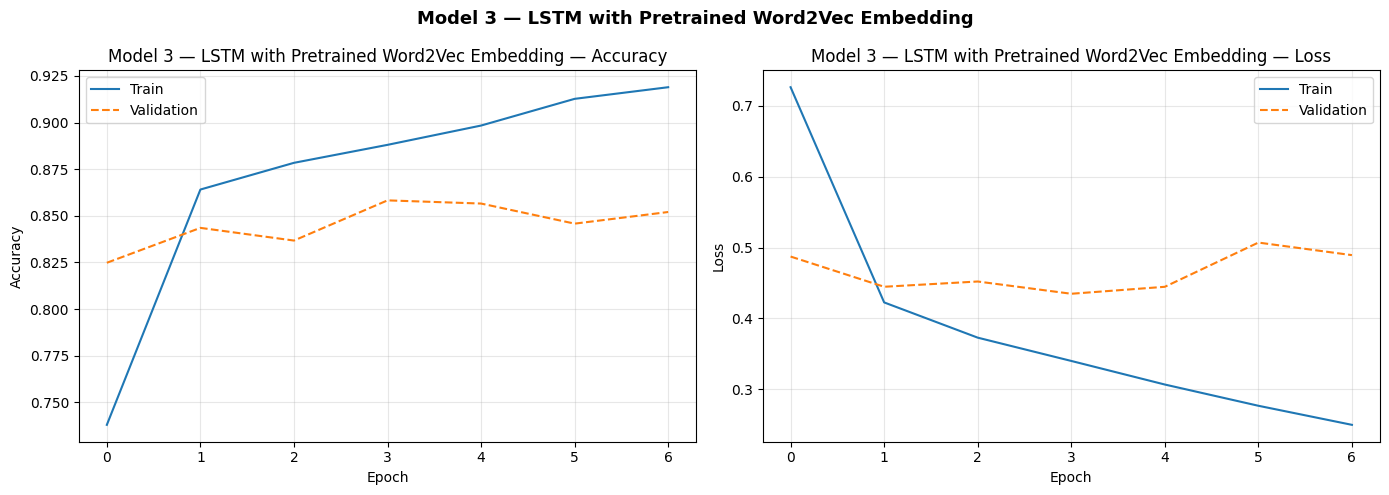

In [ ]:
plot_history(word2vec_lstm_history, "Model 3 — LSTM with Pretrained Word2Vec Embedding")

**Evaluate the models using accuracy**

In [48]:
# Evaluate Model 1: Simple RNN
rnn_loss, rnn_acc = rnn_model.evaluate(x_test_padded, y_test, verbose=0)

print("Model 1: Simple RNN")
print("Accuracy:", rnn_acc)
print("Loss:", rnn_loss)

Model 1: Simple RNN
Accuracy: 0.800000011920929
Loss: 0.5828272700309753


In [49]:
# Evaluate Model 2: LSTM with trainable embedding
lstm_loss, lstm_acc = lstm_model.evaluate(x_test_padded, y_test, verbose=0)

print("Model 2: LSTM with Trainable Embedding")
print("Accuracy:", lstm_acc)
print("Loss:", lstm_loss)

Model 2: LSTM with Trainable Embedding
Accuracy: 0.8303855061531067
Loss: 0.5041166543960571


In [50]:
# Evaluate Model 3: LSTM with pretrained Word2Vec embedding
w2v_loss, w2v_acc = word2vec_lstm_model.evaluate(x_test_padded, y_test, verbose=0)

print("Model 3: LSTM with Pretrained Word2Vec Embedding")
print("Accuracy:", w2v_acc)
print("Loss:", w2v_loss)

Model 3: LSTM with Pretrained Word2Vec Embedding
Accuracy: 0.8426303863525391
Loss: 0.46091559529304504


**Compare model performance**

In [51]:
# Get predictions for Model 1: Simple RNN
rnn_prob = rnn_model.predict(x_test_padded, verbose=0)
rnn_pred = np.argmax(rnn_prob, axis=1)

print("Simple RNN predictions done.")

Simple RNN predictions done.


In [52]:
# Get predictions for Model 2: LSTM with trainable embedding
lstm_prob = lstm_model.predict(x_test_padded, verbose=0)
lstm_pred = np.argmax(lstm_prob, axis=1)

print("LSTM predictions done.")

LSTM predictions done.


In [53]:
# Get predictions for Model 3: LSTM with pretrained Word2Vec embedding
w2v_prob = word2vec_lstm_model.predict(x_test_padded, verbose=0)
w2v_pred = np.argmax(w2v_prob, axis=1)

print("Word2Vec LSTM predictions done.")

Word2Vec LSTM predictions done.


In [54]:
# Create a simple comparison table

comparison_df = pd.DataFrame({
    "model": [
        "Simple RNN",
        "LSTM with Trainable Embedding",
        "LSTM with Pretrained Word2Vec"
    ],
    "test_accuracy": [
        rnn_acc,
        lstm_acc,
        w2v_acc
    ],
    "test_loss": [
        rnn_loss,
        lstm_loss,
        w2v_loss
    ],
    "total_parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        word2vec_lstm_model.count_params()
    ]
})

comparison_df

,model,test_accuracy,test_loss,total_parameters
0,Simple RNN,0.800000,0.582827,1010885
1,LSTM with Trainable Embedding,0.830386,0.504117,1042565
2,LSTM with Pretrained Word2Vec,0.842630,0.460916,3093765


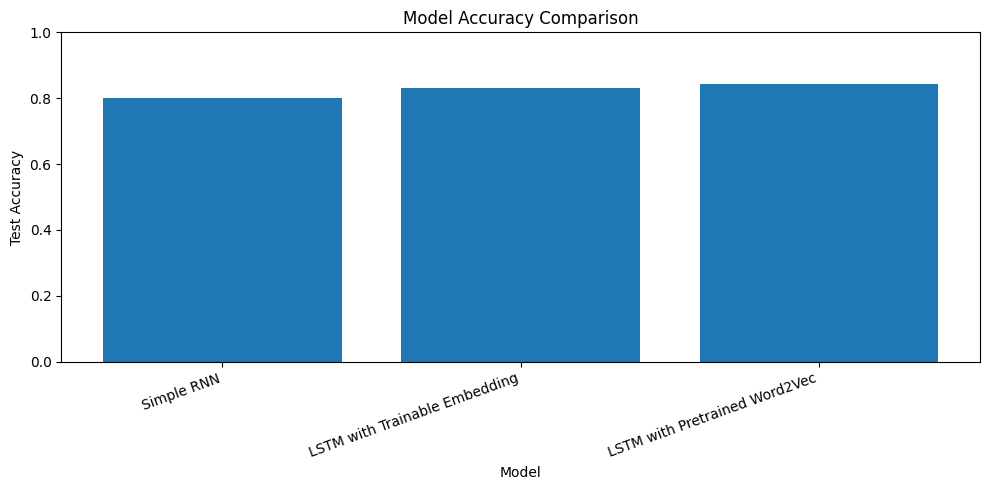

In [55]:
# Bar chart: compare test accuracy

plt.figure(figsize=(10, 5))
plt.bar(comparison_df["model"], comparison_df["test_accuracy"])

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

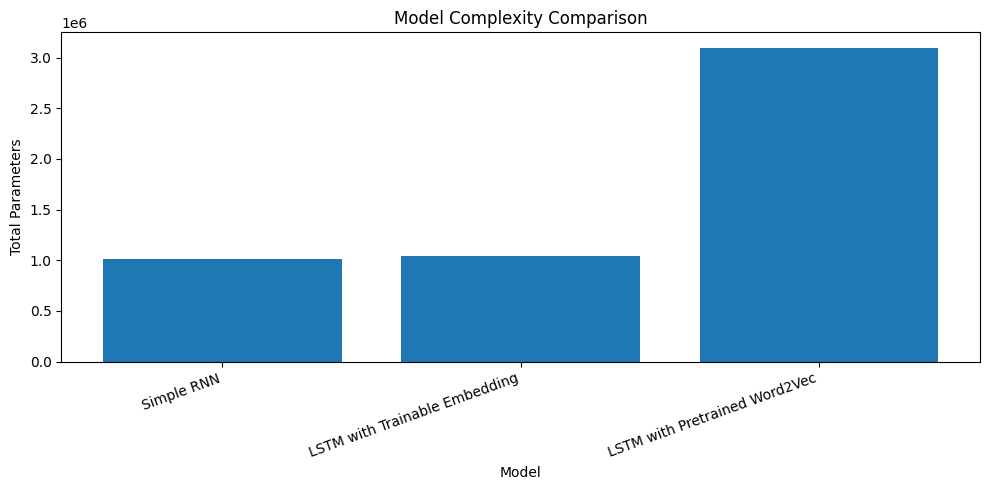

In [56]:
# Bar chart: compare model complexity using total parameters

plt.figure(figsize=(10, 5))
plt.bar(comparison_df["model"], comparison_df["total_parameters"])

plt.xlabel("Model")
plt.ylabel("Total Parameters")
plt.title("Model Complexity Comparison")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

In [57]:
# Print final comparison clearly

print("Model Comparison")

for i in range(len(comparison_df)):
    print("Model:", comparison_df.loc[i, "model"])
    print("Accuracy:", comparison_df.loc[i, "test_accuracy"])
    print("Loss:", comparison_df.loc[i, "test_loss"])
    print("Total parameters:", comparison_df.loc[i, "total_parameters"])
    print()

Model Comparison
Model: Simple RNN
Accuracy: 0.800000011920929
Loss: 0.5828272700309753
Total parameters: 1010885

Model: LSTM with Trainable Embedding
Accuracy: 0.8303855061531067
Loss: 0.5041166543960571
Total parameters: 1042565

Model: LSTM with Pretrained Word2Vec
Accuracy: 0.8426303863525391
Loss: 0.46091559529304504
Total parameters: 3093765



**Confusion Matrix**

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_cm(y_true, y_pred, model_name: str):
    """
    Confusion matrix:
    Rows = actual labels
    Columns = predicted labels

    Diagonal cells = correct predictions
    Off-diagonal cells = wrong predictions
    """

    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Create plot size
    fig, ax = plt.subplots(figsize=(10, 8))

    # Display confusion matrix with real category names
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    ).plot(ax=ax, xticks_rotation=45, colorbar=True)

    # Add title
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=13)

    plt.tight_layout()
    plt.show()


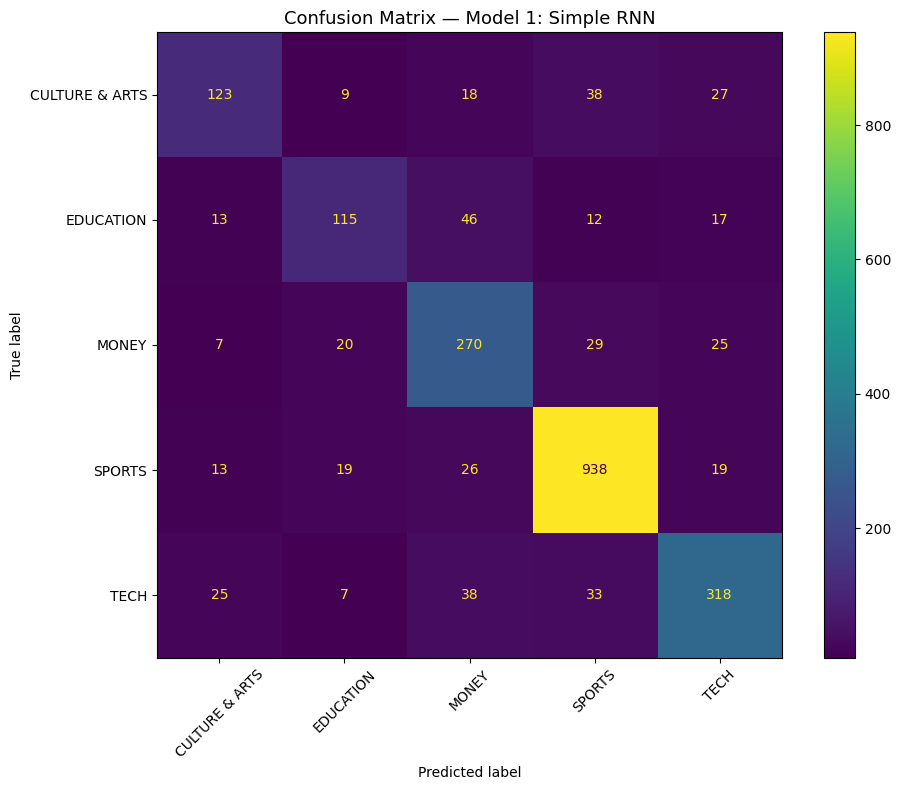

In [59]:
# Confusion matrix for Model 1
plot_cm(y_test, rnn_pred, "Model 1: Simple RNN")

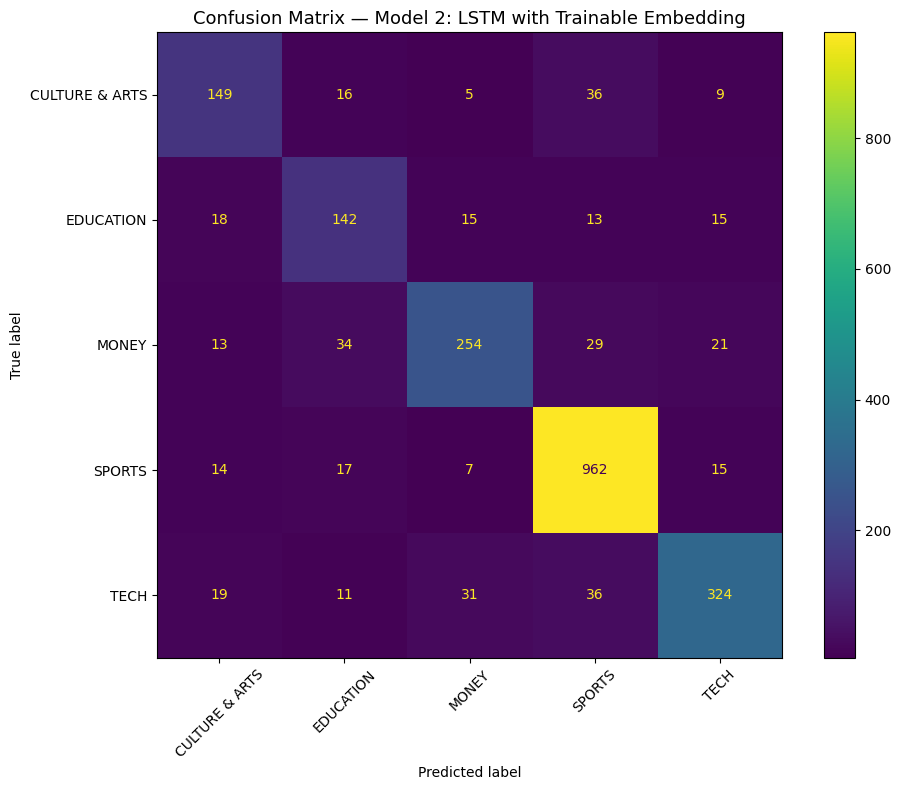

In [60]:
# Confusion matrix for Model 2
plot_cm(y_test, lstm_pred, "Model 2: LSTM with Trainable Embedding")

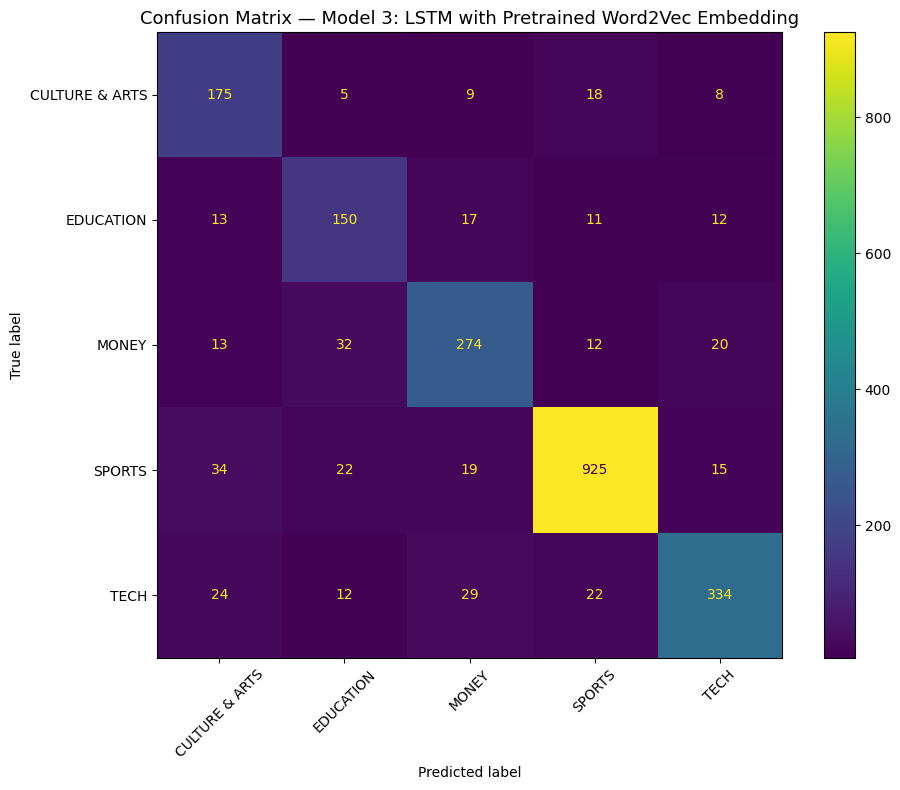

In [61]:
# Confusion matrix for Model 3
plot_cm(y_test, w2v_pred, "Model 3: LSTM with Pretrained Word2Vec Embedding")

**Classification Report**

In [62]:
from sklearn.metrics import classification_report

# Classification report for Model 1: Simple RNN

print("Classification Report — Model 1: Simple RNN\n")
print(classification_report(
    y_test,
    rnn_pred,
    target_names=label_encoder.classes_
))

Classification Report — Model 1: Simple RNN

                precision    recall  f1-score   support

CULTURE & ARTS       0.68      0.57      0.62       215
     EDUCATION       0.68      0.57      0.62       203
         MONEY       0.68      0.77      0.72       351
        SPORTS       0.89      0.92      0.91      1015
          TECH       0.78      0.76      0.77       421

      accuracy                           0.80      2205
     macro avg       0.74      0.72      0.73      2205
  weighted avg       0.80      0.80      0.80      2205



In [63]:
# Classification report for Model 2: LSTM with trainable embedding

print("Classification Report — Model 2: LSTM with Trainable Embedding\n")
print(classification_report(
    y_test,
    lstm_pred,
    target_names=label_encoder.classes_
))

Classification Report — Model 2: LSTM with Trainable Embedding

                precision    recall  f1-score   support

CULTURE & ARTS       0.70      0.69      0.70       215
     EDUCATION       0.65      0.70      0.67       203
         MONEY       0.81      0.72      0.77       351
        SPORTS       0.89      0.95      0.92      1015
          TECH       0.84      0.77      0.80       421

      accuracy                           0.83      2205
     macro avg       0.78      0.77      0.77      2205
  weighted avg       0.83      0.83      0.83      2205



In [64]:
# Classification report for Model 3: LSTM with pretrained Word2Vec embedding

print("Classification Report — Model 3: LSTM with Pretrained Word2Vec Embedding\n")

print(classification_report(
    y_test,
    w2v_pred,
    target_names=label_encoder.classes_
))

Classification Report — Model 3: LSTM with Pretrained Word2Vec Embedding

                precision    recall  f1-score   support

CULTURE & ARTS       0.68      0.81      0.74       215
     EDUCATION       0.68      0.74      0.71       203
         MONEY       0.79      0.78      0.78       351
        SPORTS       0.94      0.91      0.92      1015
          TECH       0.86      0.79      0.82       421

      accuracy                           0.84      2205
     macro avg       0.79      0.81      0.80      2205
  weighted avg       0.85      0.84      0.84      2205



**Best model**

In [65]:
# Sort models by test accuracy from highest to lowest
best_model = comparison_df.sort_values(
    by="test_accuracy",
    ascending=False
)

best_model

,model,test_accuracy,test_loss,total_parameters
2,LSTM with Pretrained Word2Vec,0.842630,0.460916,3093765
1,LSTM with Trainable Embedding,0.830386,0.504117,1042565
0,Simple RNN,0.800000,0.582827,1010885


# Error Analysis

**Choose model for error analysis**

In [66]:
# Automatically pick the best model based on test accuracy

best_idx = comparison_df["test_accuracy"].idxmax()

best_name = comparison_df.loc[best_idx, "model"]

best_pred = [rnn_pred, lstm_pred, w2v_pred][best_idx]

best_accuracy = comparison_df.loc[best_idx, "test_accuracy"]

print("Best model:", best_name)
print("Best accuracy:", best_accuracy)

Best model: LSTM with Pretrained Word2Vec
Best accuracy: 0.8426303863525391


**Create error analysis dataframe**

In [67]:
# Build a dataframe showing original headline, cleaned version, actual label, and predicted label

error_df = pd.DataFrame({
    "original_headline": df_text.loc[X_test.index, text_col].values,
    "cleaned_headline": X_test.values,
    "actual_label": label_encoder.inverse_transform(y_test),
    "predicted_label": label_encoder.inverse_transform(best_pred),
})

**Find misclassified**

In [68]:
# Keep only the rows where actual label and predicted label are different

misclassified = error_df[
    error_df["actual_label"] != error_df["predicted_label"]
]

print("Misclassified:", len(misclassified), "/", len(error_df))

print("Misclassification percentage:")
print((len(misclassified) / len(error_df)) * 100)

Misclassified: 347 / 2205
Misclassification percentage:
15.736961451247167


In [69]:
# Show 3 examples where the model made a mistake
print("3 Sample Misclassifications:")
for i, (_, row) in enumerate(misclassified.head(3).iterrows(), 1):
    print(f"Example {i}:")
    print(f"  Headline  : {row['original_headline']}")
    print(f"  Actual    : {row['actual_label']}")
    print(f"  Predicted : {row['predicted_label']}")
    print()

3 Sample Misclassifications:
Example 1:
  Headline  : The Game Boy Of Your Childhood Dreams Finally Exists
  Actual    : TECH
  Predicted : EDUCATION

Example 2:
  Headline  : Judicial Negligence Compounds Political Negligence In South Carolina
  Actual    : EDUCATION
  Predicted : SPORTS

Example 3:
  Headline  : Tales From The Autism Spectrum: My Friend AmberDawn...
  Actual    : CULTURE & ARTS
  Predicted : EDUCATION



**Display in scatter plot**

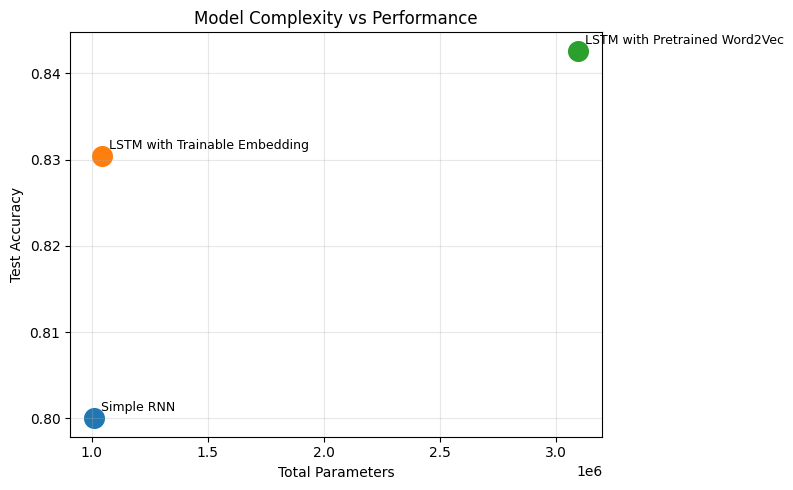

In [70]:
# Scatter plot: x = model complexity, y = accuracy
# This shows whether more parameters actually improve performance

plt.figure(figsize=(8, 5))

for i, row in comparison_df.iterrows():
    plt.scatter(
        row["total_parameters"],
        row["test_accuracy"],
        s=200
    )

    plt.annotate(
        row["model"],
        xy=(row["total_parameters"], row["test_accuracy"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Total Parameters")
plt.ylabel("Test Accuracy")
plt.title("Model Complexity vs Performance")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Final Observation

The misclassified examples show that some headlines are difficult to classify because they contain limited context. A short headline may include words that are common across multiple categories. For example, technology-related words may also appear in education or money-related news, which can confuse the model.

The Simple RNN model is less complex and faster, but it may not capture long-term word relationships effectively. The LSTM model is more complex because it uses memory gates, allowing it to understand sequence patterns better than Simple RNN. The pretrained Word2Vec LSTM model uses external word embeddings, which can improve word meaning representation, but it may not always perform best if the pretrained vocabulary does not match the dataset vocabulary.

Possible reasons for incorrect predictions include short headline length, overlapping words between categories, loss of meaning after preprocessing, and limited context in the text. Some important words may also be removed during stopword removal or not found in the pretrained embedding vocabulary.

Potential improvements include using more training data, tuning hyperparameters, increasing embedding dimensions, using dropout to reduce overfitting, trying bidirectional LSTM, using better pretrained embeddings, and applying transformer-based models such as BERT for stronger contextual understanding.

# **GUI for Real Time Prediction:**

In [ ]:
!pip install gradio

**Select best trained model**

In [ ]:
# Use the best performing model for the GUI
final_model = [rnn_model, lstm_model, word2vec_lstm_model][best_idx]

print("GUI powered by:", best_name)

GUI powered by: LSTM with Pretrained Word2Vec


**Prediction function**

In [ ]:
def predict_category(raw_text: str):
    """
    Takes a raw headline typed by the user and returns:
    - predicted category
    - confidence score

    The same cleaning steps used during training are applied here.
    """

    # clean the input headline
    cleaned = clean_text(raw_text)

    if not cleaned:
        return "Input too short after cleaning", "0.00%"

    # convert text into sequence of numbers
    sequence = tokenizer.texts_to_sequences([cleaned])

    # pad sequence using the same max_length used during training
    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    # predict probabilities
    proba = final_model.predict(padded, verbose=0)[0]

    # get predicted class
    predicted_idx = int(np.argmax(proba))

    category = label_encoder.inverse_transform([predicted_idx])[0]

    confidence = f"{proba[predicted_idx] * 100:.2f}%"

    return category, confidence

**Test prediction function**

In [ ]:
predict_category("Documenting A Way Of Life Along The River Gambia")

('CULTURE & ARTS', '79.35%')

**Build Gradio GUI**

In [ ]:
import gradio as gr
# Build and launch the Gradio interface

interface = gr.Interface(
    fn=predict_category,

    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter a news headline here...",
        label="Input Headline"
    ),

    outputs=[
        gr.Textbox(label="Predicted Category"),
        gr.Textbox(label="Confidence Score")
    ],

    title="News Headline Category Classifier",

    description=f"Type a headline and click Submit to get the predicted category.\nPowered by: {best_name}",

    examples=[
        ["Scientists discover new treatment for Alzheimer's disease"],
        ["Stock market rallies as Fed cuts interest rates"],
        ["Premier League title race goes to final day"],
        ["White House announces new climate change policy"]
    ],

    theme=gr.themes.Soft()
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://05d4227a1fe983ebc0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
